In [96]:
using Plots, Agents, Random, DataFrames

# Ланжевена, Фокерапласка

### Основная формула

In [97]:
function mutualism_1!(du, u, p, t)
    X, Y = u
    c1, c2, p1, p2 = p

    du[1] = -c1*X + p1*X*Y
    du[2] = -c2*Y + p2*X*Y
end

mutualism_1! (generic function with 1 method)

### Добавление фактора насыщения

In [98]:
function mutualism_2!(du, u, p, t)
    X, Y = u
    c1, c2, p1, p2, d1, d2 = p

    du[1] = -c1*X + p1*X*Y/(1+d1*Y)
    du[2] = -c2*Y + p2*X*Y/(1+d2*X)
end

mutualism_2! (generic function with 1 method)

### Дополнение формулы фактором внутривидовой конкуренции

In [99]:
function mutualism_3!(du, u, p, t)
    X, Y = u
    c1, c2, p1, p2, d1, d2, e1, e2 = p

    du[1] = -c1*X + p1*X*Y/(1+d1*Y) - e1*X*X
    du[2] = -c2*Y + p2*X*Y/(1+d2*X) - e2*Y*Y
end

mutualism_3! (generic function with 1 method)

### Имитационное

In [ ]:

p = plot(size=(1000, 600))
plot!(p,
      xlabel="Время, t",
      ylabel="Численность популяции, N",
      title="Имитационное моделирование",
      titlefontsize=14,
      legend=:bottomright,
      legendfontsize=12)

p_phase = plot(size=(1000, 600))
plot!(p_phase,
      xlabel="Вид X",
      ylabel="Вид Y",
      title="Фазовый портрет",
      titlefontsize=14,
      legend=:bottomright,
      legendfontsize=12)

# Параметры модели
X = 20.0
Y = 19.0
c1, c2, p1, p2, d1, d2, e1, e2 = (0.6, 0.6, 0.2, 0.2, 0.2, 0.2, 0.01, 0.01)
dt = 0.01

# Имитационное моделирование
X_hist = [X]
Y_hist = [Y]

Random.seed!(50)
T = []
for t in 0:0.5:50
    push!(T, t)
end

for t in T
    # Детерминистическая часть
    dX = -c1*X + p1*X*Y/(1+d1*Y) - e1*X*X
    dY = -c2*Y + p2*X*Y/(1+d2*X) - e2*Y*Y

    # Стохастическая часть
    noise1 = 0.01  * randn()
    noise2 = 0.01  * randn()

    X = max(0.0, X + dX + noise1)
    Y = max(0.0, Y + dY + noise2)

    push!(X_hist, X)
    push!(Y_hist, Y)
end


plot!(p, T, X_hist,
      linewidth=2,
      color=:blue,
      label="Вид X",
      linestyle=:solid)

plot!(p, T, Y_hist,
      linewidth=2,
      color=:red,
      label="Вид Y",
      linestyle=:solid)

plot!(p_phase, X_hist, Y_hist,
      linewidth=2,
      color=:blue,
      label="",
      linestyle=:solid)

# Аннотации параметров
annotate!(p, 5, 0.9, text("", 12, :black, :left))
annotate!(p, 5, 0.8, text("", 12, :black, :left))


# Генерация графика
display(p)
display(p_phase)

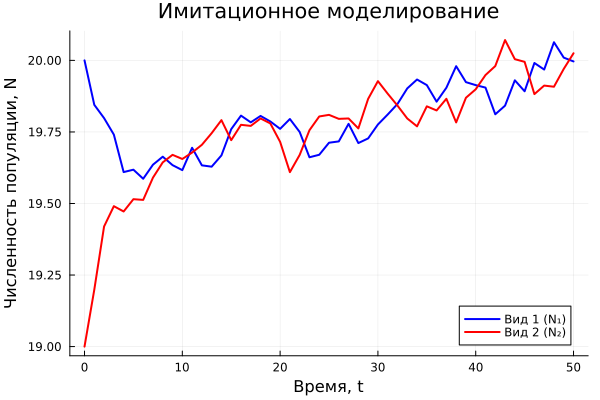

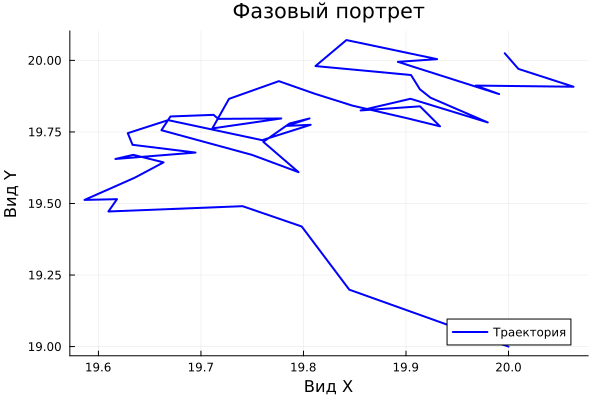

In [100]:
# Параметры модели
c1, c2, p1, p2, d1, d2, e1, e2 = (0.6, 0.6, 0.2, 0.2, 0.2, 0.2, 0.01, 0.01)

function stochastic_model(X0, Y0)
    Random.seed!(100)

    X, Y = X0, Y0
    X_hist, Y_hist = [X], [Y]

    for t in 1:50
        # Детерминистическая часть
        dX = -c1*X + p1*X*Y/(1+d1*Y) - e1*X*X
        dY = -c2*Y + p2*X*Y/(1+d2*X) - e2*Y*Y

        # Стохастическая часть
        noise1 = 0.05 * randn()
        noise2 = 0.05 * randn()

        X = max(0.0, X + dX + noise1)
        Y = max(0.0, Y + dY + noise2)

        push!(X_hist, X)
        push!(Y_hist, Y)
    end

    return X_hist, Y_hist
end

# Запуск модели
X_hist, Y_hist = stochastic_model(20.0, 19.0)
time_points = range(0, 50, length=51)

# Создание графиков
p_time = plot(0:50, [X_hist Y_hist],
              linewidth=2,
              label=["Вид 1 (N₁)" "Вид 2 (N₂)"],
              xlabel="Время, t",
              ylabel="Численность популяции, N",
              title="Имитационное моделирование",
              color=[:blue :red],
              legend=:bottomright)

p_phase = plot(X_hist, Y_hist,
               linewidth=2,
               color=:blue,
               label="Траектория",
               xlabel="Вид X",
               ylabel="Вид Y",
               title="Фазовый портрет",
               legend=:bottomright)

# Отображение
display(p_time)
display(p_phase)

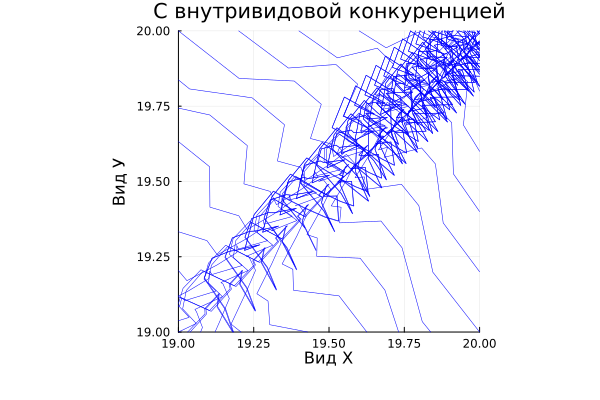

In [101]:
p_phase_2 = plot(xlabel="Вид Х\n\n",
                 ylabel="Вид У",
                 label="",
                 title="С внутривидовой конкуренцией",
                 xlims=(19, 20),
                 ylims=(19, 20),
                 legend=:right,
                 aspect_ratio=:equal)

# Объединяем оба цикла
initial_conditions = [(X, 20.0) for X in 17:0.2:20.0 ]
append!(initial_conditions, [(20.0, Y) for Y in 17:0.2:20.0])


for (X, Y) in initial_conditions
    X_hist, Y_hist = stochastic_model(X, Y)

    plot!(p_phase_2, X_hist, Y_hist,
          linewidth=0.5,
          label="",
          color=:blue)
end

display(p_phase_2)


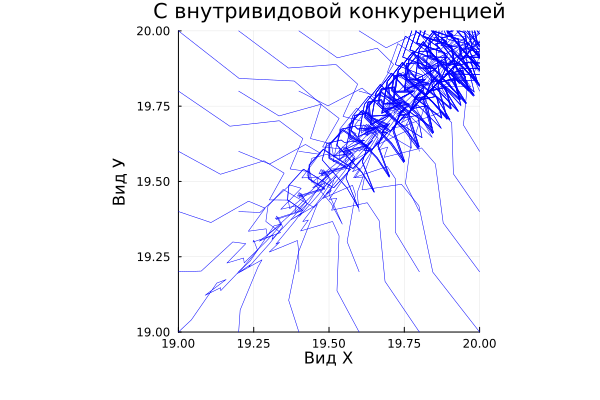

In [102]:
p_phase_2 = plot(xlabel="Вид Х\n\n",
                 ylabel="Вид У",
                 label="",
                 title="С внутривидовой конкуренцией",
                 xlims=(19, 20),
                 ylims=(19, 20),
                 legend=:right,
                 aspect_ratio=:equal)

for X in 19:0.2:20.0
    for Y in 19:0.2:20.0
        X_hist, Y_hist = stochastic_model(X, Y)

        plot!(p_phase_2, X_hist, Y_hist,
              linewidth=0.5,
              label="",
              color=:blue)
    end
end

display(p_phase_2)


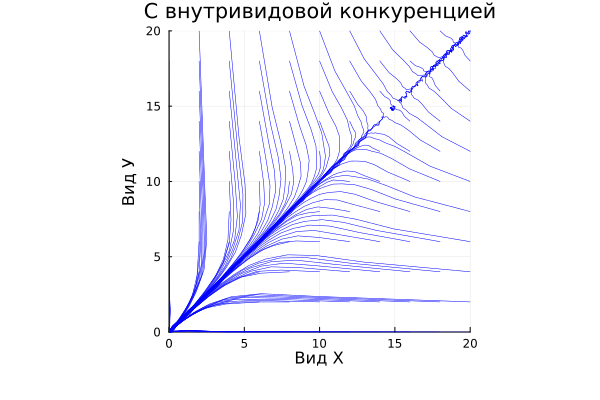

In [103]:
p_phase_2 = plot(xlabel="Вид Х\n\n",
                 ylabel="Вид У",
                 label="",
                 title="С внутривидовой конкуренцией",
                 xlims=(0, 20),
                 ylims=(0, 20),
                 legend=:right,
                 aspect_ratio=:equal)

for X in 0:2:20.0
    for Y in 0:2:20.0
        X_hist, Y_hist = stochastic_model(X, Y)

        plot!(p_phase_2, X_hist, Y_hist,
              linewidth=0.5,
              label="",
              color=:blue)
    end
end

display(p_phase_2)
